## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd
import os
import duckdb
from traj_ps.backends.bayes import BayesianTrajPS, BayesConfig
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# Import shared utility functions
from notebook_utils import (
    aggregate_vitals_labs, drop_high_missing_columns,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, biomarker_summary_stats
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ Imports successful


## LOAD

In [2]:
# Connect to MIMIC-III DuckDB
db_path = '../../data/mimic/mimiciii.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to MIMIC-III database: {db_path}")

✓ Connected to MIMIC-III database: ../../data/mimic/mimiciii.duckdb


In [3]:
# Load mechanically ventilated patients
hadm_query = """
WITH ventilated_patients AS (
    SELECT DISTINCT
        i.hadm_id::INTEGER AS hadm_id,
        MIN(ce.charttime::TIMESTAMP) as vent_start
    FROM chartevents ce
    INNER JOIN icustays i ON ce.icustay_id = i.icustay_id
    WHERE 
        ce.itemid IN (720, 223849)  -- Ventilator mode
        AND ce.value IS NOT NULL
    GROUP BY i.hadm_id
)
SELECT 
    i.subject_id::INTEGER AS subject_id,
    i.hadm_id::INTEGER AS hadm_id,
    a.admittime::TIMESTAMP as admittime,      -- Hospital admission time
    a.dischtime::TIMESTAMP as dischtime,      -- Hospital discharge time
    vp.vent_start::TIMESTAMP as vent_start,   -- Ventilation start time
    CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) as los_days,  -- Hospital LOS
    p.gender,
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) as age,
    a.hospital_expire_flag::INT as hospital_expire_flag,
    a.discharge_location
FROM icustays i
INNER JOIN patients p ON i.subject_id = p.subject_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
INNER JOIN ventilated_patients vp ON i.hadm_id = vp.hadm_id
WHERE 
    -- Filter adults
    CAST((a.admittime::DATE - p.dob::DATE) / 365.25 AS INT) BETWEEN 18 AND 90
    -- Minimum hospital stay
    AND CAST(a.dischtime::DATE - a.admittime::DATE AS REAL) >= 2.0
"""

hadm_df = conn.execute(hadm_query).fetchdf()
hadm_df.columns = hadm_df.columns.str.lower()
print(f"\n✓ Loaded {len(hadm_df):,} mechanically ventilated admissions")
print(f"  Unique patients: {hadm_df['subject_id'].nunique():,}")
print(f"  Mean hospital LOS: {hadm_df['los_days'].mean():.1f} days")
print(f"  Mortality: {hadm_df['hospital_expire_flag'].mean():.1%}")


✓ Loaded 25,340 mechanically ventilated admissions
  Unique patients: 20,132
  Mean hospital LOS: 15.2 days
  Mortality: 15.4%


In [4]:
# Sample subset
hadm_subset = hadm_df.sort_values('admittime').drop_duplicates(subset=['subject_id'])['hadm_id'].sample(min(5000, hadm_df['subject_id'].nunique()), random_state=920).tolist()
hadm_df = hadm_df[hadm_df['hadm_id'].isin(hadm_subset)]

print(f"✓ Using {hadm_df['hadm_id'].nunique():,} admissions for analysis")

✓ Using 5,000 admissions for analysis


In [5]:
# Load metadata for vitals and labs
vital_meta = pd.read_csv('../../data/mimic/vital_metadata.csv')
labs_meta = pd.read_csv('../../data/mimic/labs_metadata.csv')

lab_items = labs_meta['itemid'].to_list()
vital_items = vital_meta['itemid'].to_list()

print(f"✓ Loaded metadata: {len(vital_meta):,} vital items, {len(labs_meta):,} lab items")

✓ Loaded metadata: 43 vital items, 27 lab items


In [6]:
# Load PaO2/FiO2 ratio (P/F ratio) - key weaning predictor
# Note: PaO2/FiO2 are in labevents (blood gas measurements)
# Lower values = worse oxygenation, <200 = ARDS

bg_query = """
SELECT 
    le.hadm_id::INTEGER AS hadm_id,
    le.charttime::TIMESTAMP AS charttime,
    EXTRACT(EPOCH FROM (le.charttime::TIMESTAMP - a.admittime::TIMESTAMP)) / 86400.0 as time_days,
    MAX(CASE WHEN le.itemid = 50821 THEN CAST(le.valuenum AS REAL) END) as pao2,
    MAX(CASE WHEN le.itemid = 50816 THEN CAST(le.valuenum AS REAL) END) as fio2
FROM labevents le
INNER JOIN admissions a ON le.hadm_id = a.hadm_id
WHERE 
    le.itemid IN (50821, 50816)
    AND le.hadm_id::INTEGER IN {hadm_ids}
    AND le.charttime::TIMESTAMP BETWEEN a.admittime::TIMESTAMP AND a.dischtime::TIMESTAMP
GROUP BY le.hadm_id, le.charttime, a.admittime
HAVING MAX(CASE WHEN le.itemid = 50821 THEN CAST(le.valuenum AS REAL) END) IS NOT NULL
    AND MAX(CASE WHEN le.itemid = 50816 THEN CAST(le.valuenum AS REAL) END) IS NOT NULL
"""

bg_df = conn.execute(bg_query.format(hadm_ids=tuple(hadm_subset))).fetchdf()
bg_df.columns = bg_df.columns.str.lower()

# Calculate P/F ratio
bg_df['pf_ratio'] = bg_df['pao2'] / bg_df['fio2'] * 100
bg_df = bg_df[(bg_df['pf_ratio'] >= 50) & (bg_df['pf_ratio'] <= 600)]

print(f"\n✓ Loaded {len(bg_df):,} blood gas measurements")
print(f"  Admissions with P/F ratio: {bg_df['hadm_id'].nunique():,}")
print(f"  Mean P/F ratio: {bg_df['pf_ratio'].mean():.0f}")


✓ Loaded 20,798 blood gas measurements
  Admissions with P/F ratio: 2,934
  Mean P/F ratio: 237


In [7]:
# Load vitals for general health status
vitals_query = """
SELECT chartevents.subject_id::INTEGER AS subject_id
    , chartevents.hadm_id::INTEGER AS hadm_id
    , chartevents.charttime::TIMESTAMP AS charttime
    , chartevents.itemid::INTEGER AS itemid
    , chartevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
        FROM chartevents
                 INNER JOIN admissions
                            ON chartevents.subject_id = admissions.subject_id
                                AND chartevents.hadm_id = admissions.hadm_id
                                AND chartevents.charttime::TIMESTAMP between
                                   (admissions.admittime::TIMESTAMP)
                                   AND (admissions.dischtime::TIMESTAMP)
                                AND itemid::INTEGER in {itemids}
                                AND chartevents.hadm_id::INTEGER in {hadm_ids}
      AND chartevents.error::INTEGER IS DISTINCT FROM 1 
"""

vitals_df = conn.execute(vitals_query.format(itemids=vital_items, hadm_ids=tuple(hadm_subset))).fetchdf()
vitals_df.columns = vitals_df.columns.str.lower()
print(f"\n✓ Loaded {len(vitals_df):,} vital signs")
print(f"  Admissions: {vitals_df['hadm_id'].nunique():,}")


✓ Loaded 6,461,793 vital signs
  Admissions: 5,000


In [8]:
# Load labs for general health status
labs_query = """
SELECT labevents.subject_id::INTEGER AS subject_id
      , labevents.hadm_id::INTEGER AS hadm_id
      , labevents.charttime::TIMESTAMP AS charttime
      , labevents.itemid::INTEGER AS itemid
      , labevents.valuenum::DOUBLE AS valuenum
      , admissions.admittime::TIMESTAMP AS admittime
FROM labevents
          INNER JOIN admissions
                    ON labevents.subject_id = admissions.subject_id
                        AND labevents.hadm_id = admissions.hadm_id
                        AND labevents.charttime::TIMESTAMP between
                            (admissions.admittime::TIMESTAMP)
                            AND (admissions.dischtime::TIMESTAMP)
                        AND itemid::INTEGER IN {itemids}
                        AND labevents.hadm_id::INTEGER IN {hadm_ids}
"""

labs_df = conn.execute(labs_query.format(itemids=tuple(lab_items), hadm_ids=tuple(hadm_subset))).fetchdf()
labs_df.columns = labs_df.columns.str.lower()
print(f"✓ Loaded {len(labs_df):,} lab values")
print(f"  Admissions: {labs_df['hadm_id'].nunique():,}")

✓ Loaded 1,387,145 lab values
  Admissions: 4,987


## PREPROCESS

In [9]:
# Use shared utility function for standardized vitals/labs aggregation
vitals_labs_pivot = aggregate_vitals_labs(
    vitals_df=vitals_df,
    labs_df=labs_df,
    vital_meta=vital_meta,
    labs_meta=labs_meta
)


print(f"\n✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):")
print(f"  Total daily observations: {len(vitals_labs_pivot):,}")
print(f"  Total features: {len([c for c in vitals_labs_pivot.columns])}")
print(f"  Example features: {list(vitals_labs_pivot.columns[2:8])}")


✓ Processed vitals + labs with min/max/mean aggregation (using shared utilities):
  Total daily observations: 63,982
  Total features: 87
  Example features: ['BICARBONATE_min', 'BILIRUBIN_min', 'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min']


In [10]:
vitals_labs_imputed = vitals_labs_pivot.groupby('hadm_id').ffill()

# Special handling for Weight - use both forward and backward fill
vitals_labs_imputed['Weight_mean'] = vitals_labs_imputed.groupby('hadm_id')['Weight_mean'].bfill()

# Use shared utility function for dropping high-missing columns
vitals_labs_clean, dropped_cols = drop_high_missing_columns(
    df=vitals_labs_imputed,
    threshold=0.2,
)


vitals_labs_clean = vitals_labs_clean.reset_index().drop(columns=['admittime'])

hadm_df['admittime'] = pd.to_datetime(hadm_df['admittime'])

hadm_final = hadm_df.merge(vitals_labs_clean, on=['hadm_id'], how='inner')
hadm_final['time_day'] = ((hadm_final['charttime'] - hadm_final['admittime']).dt.total_seconds() / 86400.0).astype(int)

print(f"\n✓ Imputation and cleanup (using shared utilities):")
print(f"  Dropped {len(dropped_cols)} high-missing columns (>20%)")
print(f"  Remaining features: {len([c for c in vitals_labs_imputed.columns if c not in ['hadm_id']])}")
print(f"  Overall missing rate: {vitals_labs_imputed.isna().mean().mean():.2%}")



✓ Imputation and cleanup (using shared utilities):
  Dropped 9 high-missing columns (>20%)
  Remaining features: 87
  Overall missing rate: 8.59%


In [11]:
# Calculate baseline P/F ratio (first 24h on ventilator)
# Merge with hadm_df to get vent_start timestamp
bg_df = bg_df.merge(hadm_df[['hadm_id', 'vent_start']], on='hadm_id', how='left')
bg_df['charttime'] = pd.to_datetime(bg_df['charttime'])

first_24h = bg_df[
    bg_df['charttime'] <= bg_df['vent_start'] + pd.Timedelta(hours=24)
]

baseline_pf = first_24h.groupby('hadm_id')['pf_ratio'].first().reset_index()
baseline_pf.columns = ['hadm_id', 'baseline_pf_ratio']

print(f"\nBaseline P/F ratio (first 24h):")
print(f"   Admissions with baseline: {len(baseline_pf):,}")
print(f"   Mean: {baseline_pf['baseline_pf_ratio'].mean():.0f}")
print(f"   Median: {baseline_pf['baseline_pf_ratio'].median():.0f}")


Baseline P/F ratio (first 24h):
   Admissions with baseline: 2,493
   Mean: 272
   Median: 262


In [12]:
# Filter admissions with sufficient measurements
pf_counts = bg_df.groupby('hadm_id').size()
valid_hadm_ids = pf_counts[pf_counts >= 3].index

pf_filtered = bg_df[bg_df['hadm_id'].isin(valid_hadm_ids)]
hadm_final = hadm_final[hadm_final['hadm_id'].isin(valid_hadm_ids)].merge(
    baseline_pf, on='hadm_id', how='inner'
)

print(f"\nFiltering:")
print(f"   Admissions with ≥3 P/F measurements: {len(hadm_final):,}")


Filtering:
   Admissions with ≥3 P/F measurements: 35,035


In [13]:
# Create P/F ratio time series
pf_filtered['time_day'] = np.floor(pf_filtered['time_days']).astype(int)

pf_ts = pf_filtered[['hadm_id', 'time_days', 'time_day', 'pf_ratio']].merge(
    hadm_final[['hadm_id', 'baseline_pf_ratio', 'age', 'gender', 'hospital_expire_flag']].drop_duplicates(),
    on='hadm_id',
    how='left'
)

pf_ts['pf_improvement'] = pf_ts['pf_ratio'] - pf_ts['baseline_pf_ratio']

print(f"\nP/F Ratio Time Series:")
print(f"   Total measurements: {len(pf_ts):,}")
print(f"   Mean improvement: {pf_ts['pf_improvement'].mean():.0f}")


P/F Ratio Time Series:
   Total measurements: 22,557
   Mean improvement: 5


In [19]:
hadm_final.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'vent_start',
       'los_days', 'gender', 'age', 'hospital_expire_flag',
       'discharge_location', 'charttime', 'ANION GAP_min', 'BICARBONATE_min',
       'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min',
       'GLUCOSE_min', 'Glucose_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min',
       'HeartRate_min', 'INR_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'Weight_min', 'ANION GAP_max', 'BICARBONATE_max', 'BUN_max',
       'CHLORIDE_max', 'CREATININE_max', 'DiasBP_max', 'GLUCOSE_max',
       'Glucose_max', 'HEMATOCRIT_max', 'HEMOGLOBIN_max', 'HeartRate_max',
       'INR_max', 'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max',
       'PLATELET_max', 'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max',
       'SODIUM_max', 'SpO2_max', 'SysBP_max', 'TempC_max', 'WBC_m

In [14]:
hadm_final = hadm_final.merge(pf_ts[['hadm_id', 'time_day', 'pf_ratio', 'pf_improvement']].groupby(['hadm_id', 'time_day']).last().reset_index(), on=['hadm_id', 'time_day'], how='left')

In [15]:
# Save
os.makedirs('../../results/mimic/ventilator', exist_ok=True)
pf_ts.to_csv('../../results/mimic/ventilator/pf_ratio_timeseries.csv', index=False)
hadm_final.to_csv('../../results/mimic/ventilator/hadm_cohort.csv', index=False)

print(f"\n✓ Saved preprocessed data")


✓ Saved preprocessed data


## TRAJ PROBS

**Note**: Run `ventilator_trajs.py` to compute trajectory probabilities.

Key configuration:
- `window_years=3.0` (3 days lookback)
- `flat_thr=10` (stable P/F ratio within ±10)
- `incline_thr=-30` (improving: P/F increasing >30 points/day)
- **P/F ratio INCREASES = improving** (higher = better oxygenation)

In [16]:
# Load trajectory probabilities
trajectory_probs = pd.read_csv('../../results/mimic/ventilator/pf_trajectory_probs_bayes.csv')
print(f"✓ Loaded trajectory probabilities: {len(trajectory_probs):,} timepoints")

✓ Loaded trajectory probabilities: 6,170 timepoints


In [18]:
trajectory_probs.columns

Index(['hadm_id', 'time_days', 'time_day', 'pf_ratio', 'baseline_pf_ratio',
       'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement'],
      dtype='object')


✓ Saved: pf_trajectory_distribution.png


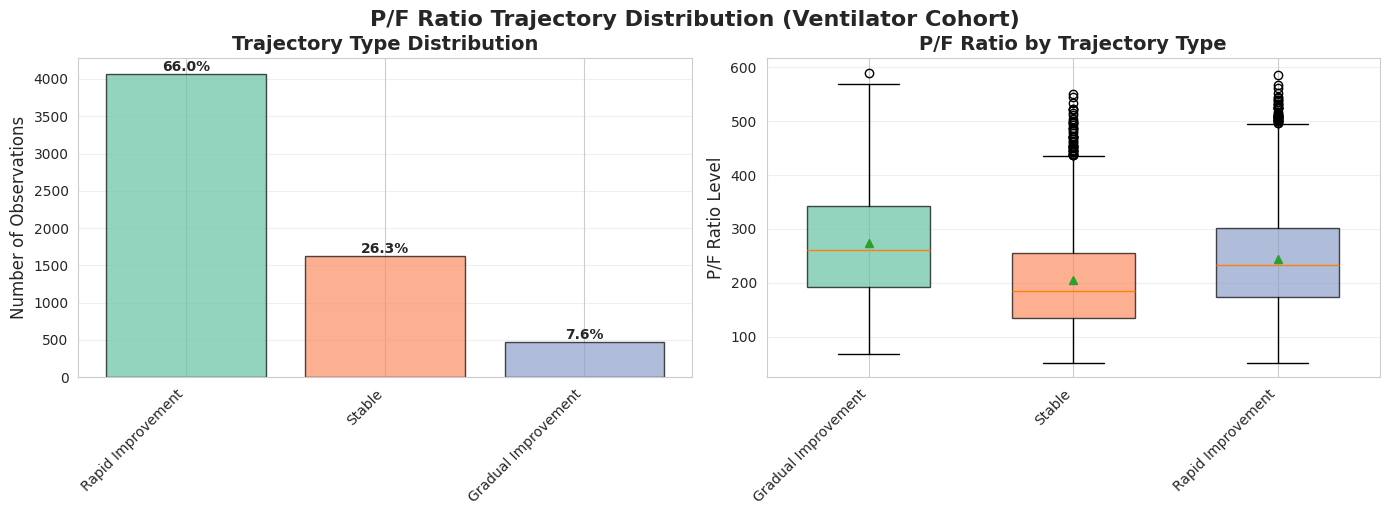

In [19]:
# Visualize P/F ratio trajectory distributions (using shared utility)
trajectory_probs['dominant_traj'] = trajectory_probs[[
    'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement'
]].idxmax(axis=1).str.replace('prob_', '')

fig, axes = plot_trajectory_distribution(
    df=trajectory_probs.dropna(subset=['pf_ratio']),
    traj_col='dominant_traj',
    biomarker_col='pf_ratio',
    biomarker_name='P/F Ratio'
)
plt.suptitle('P/F Ratio Trajectory Distribution (Ventilator Cohort)', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../../results/mimic/ventilator/pf_trajectory_distribution.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: pf_trajectory_distribution.png")
plt.show()

## STANDARD TRAJ FEATURES

In [20]:
LOOKBACK_DAYS = 3
pf_summary_3d = biomarker_summary_stats(pf_ts, 'pf_ratio', lookback_days=LOOKBACK_DAYS)
print(f"\n✓ Calculated P/F ratio summary stats over last {LOOKBACK_DAYS} days")
print(f"   Example stats:\n{pf_summary_3d.head()}")
pf_summary_3d.to_csv('../../results/mimic/ventilator/pf_ratio_summary_3d.csv', index=False)


✓ Calculated P/F ratio summary stats over last 3 days
   Example stats:
   hadm_id  time_day  pf_ratio_mean_3d  pf_ratio_max_3d  pf_ratio_min_3d  \
0   100011         0        398.000000       419.999969            376.0   
1   100011         2        381.166656       419.999969            347.5   
2   100011         8        382.500000       382.500000            382.5   
3   100108         0        149.801590       165.000000            130.0   
4   100108         1        162.851196       240.000015            130.0   

   pf_ratio_change_3d  pf_ratio_linear_trend_3d  pf_ratio_std_3d  
0           43.999969                 76.706969        31.112677  
1          -28.500000                -20.410095        36.525089  
2            0.000000                 23.840028              NaN  
3           26.666672                 83.261630        14.198481  
4          110.000015                 38.165753        33.770226  


## DEFINE OUTCOME

**Outcome**: Successful Extubation (vs reintubation within 48h)
- Success = extubated AND no reintubation within 48h
- Failure = reintubation OR death within 48h of extubation

In [21]:
# Detect extubation and reintubation events
# This is complex in MIMIC - simplified approach:
# Use ventilator discontinuation and reinitiation

extubation_query = """
SELECT DISTINCT
    i.hadm_id::INTEGER,
    MIN(EXTRACT(EPOCH FROM (ce.charttime::timestamp - a.admittime::timestamp)) / 86400) as extubation_day
FROM chartevents ce
INNER JOIN icustays i ON ce.icustay_id = i.icustay_id
INNER JOIN admissions a ON i.hadm_id = a.hadm_id
WHERE 
    ce.itemid IN (227579)  -- Extubation
    AND i.hadm_id::INT IN {hadm_ids}
GROUP BY i.hadm_id
"""

extubation_df = conn.execute(extubation_query.format(hadm_ids=tuple(hadm_final['hadm_id']))).fetchdf()
extubation_df.columns = extubation_df.columns.str.lower()
print(f"✓ Detected extubation in {len(extubation_df):,} admissions")

# For this example, we'll use mortality as a proxy for weaning failure
# In practice, you'd track ventilator-free days and reintubation

✓ Detected extubation in 15 admissions


In [22]:
hadm_final = hadm_final.drop_duplicates(subset=['hadm_id', 'time_day'])

In [34]:
# Define weaning success outcome
PREDICTION_GAP_DAYS = 0.5   # 12 hours
PREDICTION_WINDOW_DAYS = 2.0  # 48 hours

print(f"Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")

weaning_events = []
n_good = 0
n_no_data = 0

for hadm_id, grp in hadm_final.groupby('hadm_id'):
    grp = grp.sort_values('time_day')
    mortality = hadm_final[hadm_final['hadm_id'] == hadm_id]['hospital_expire_flag'].iloc[0]
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_pf = grp.iloc[i]['pf_ratio']
        
        # Skip if P/F already very good (>400)
        if current_pf >= 400:
            n_good += 1
            continue
        
        # Prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1 
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = pf_ts[
            (pf_ts['hadm_id'] == hadm_id) &
            (pf_ts['time_days'] >= prediction_start) &
            (pf_ts['time_days'] <= prediction_end)
        ]
        
        if len(future_window) == 0:
            n_no_data += 1
            continue
        
        # Weaning readiness: P/F > 300 (simplified)
        weaning_ready = (future_window['pf_ratio'] >= 300).any()
        
        # Success = weaning ready AND survived
        target = int(weaning_ready and not mortality)
        
        weaning_events.append({
            'hadm_id': hadm_id,
            'time_day': current_time,
            'target_weaning_success': target,
            'current_pf_ratio': current_pf
        })

outcome_df = pd.DataFrame(weaning_events)

# CRITICAL: For each patient, keep all negative windows but only the FIRST positive event
# This ensures we predict the first successful weaning occurrence
outcome_df = outcome_df.sort_values(['hadm_id', 'time_day'])
positive_first = outcome_df[outcome_df['target_weaning_success'] == 1].groupby('hadm_id').first().reset_index()
all_negatives = outcome_df[outcome_df['target_weaning_success'] == 0]
outcome_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['hadm_id', 'time_day']).reset_index(drop=True)

print(f"\nOutcome Definition:")
print(f"   Total prediction windows: {len(outcome_df):,}")
print(f"   Unique patients: {outcome_df['hadm_id'].nunique():,}")
print(f"   Successful weaning (first per patient): {outcome_df['target_weaning_success'].sum():,}")
print(f"   Success rate: {outcome_df['target_weaning_success'].mean():.1%}")
print(f"   Avg windows/patient: {len(outcome_df) / outcome_df['hadm_id'].nunique():.1f}")
print(f"   Skipped due to good PF: {n_good:,}")
print(f"   Skipped due to no future data: {n_no_data:,}")

Prediction Configuration:
   Gap:    0.5 days
   Window: 2.0 days

Outcome Definition:
   Total prediction windows: 6,403
   Unique patients: 1,250
   Successful weaning (first per patient): 559
   Success rate: 8.7%
   Avg windows/patient: 5.1
   Skipped due to good PF: 721
   Skipped due to no future data: 16,891


In [35]:
outcome_df.groupby('hadm_id')['target_weaning_success'].sum().value_counts()

target_weaning_success
0    691
1    559
Name: count, dtype: int64

## FIT MODELS

In [27]:
hadm_final.columns

Index(['subject_id', 'hadm_id', 'admittime', 'dischtime', 'vent_start',
       'los_days', 'gender', 'age', 'hospital_expire_flag',
       'discharge_location', 'charttime', 'ANION GAP_min', 'BICARBONATE_min',
       'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min',
       'GLUCOSE_min', 'Glucose_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min',
       'HeartRate_min', 'INR_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'Weight_min', 'ANION GAP_max', 'BICARBONATE_max', 'BUN_max',
       'CHLORIDE_max', 'CREATININE_max', 'DiasBP_max', 'GLUCOSE_max',
       'Glucose_max', 'HEMATOCRIT_max', 'HEMOGLOBIN_max', 'HeartRate_max',
       'INR_max', 'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max',
       'PLATELET_max', 'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max',
       'SODIUM_max', 'SpO2_max', 'SysBP_max', 'TempC_max', 'WBC_m

In [36]:
# Merge features
prediction_dataset = outcome_df.merge(
    trajectory_probs[['hadm_id', 'time_day', 'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement']],
    on=['hadm_id', 'time_day'],
    how='left'
)

static_features = hadm_final[['hadm_id', 'age', 'gender', 'baseline_pf_ratio']].drop_duplicates()
prediction_dataset = prediction_dataset.merge(static_features, on='hadm_id', how='left')

# Derived features
prediction_dataset['prob_improving'] = (
    prediction_dataset['prob_gradual_improvement'] + 
    prediction_dataset['prob_rapid_improvement']
)
prediction_dataset['pf_adequate'] = (prediction_dataset['current_pf_ratio'] > 200).astype(int)

vitals_labs_features = ['ANION GAP_min', 'BICARBONATE_min',
       'BUN_min', 'CHLORIDE_min', 'CREATININE_min', 'DiasBP_min',
       'GLUCOSE_min', 'HEMATOCRIT_min', 'HEMOGLOBIN_min',
       'HeartRate_min', 'INR_min', 'MAGNESIUM_min', 'MeanBP_min',
       'PHOSPHATE_min', 'PLATELET_min', 'POTASSIUM_min', 'PT_min', 'PTT_min',
       'RespRate_min', 'SODIUM_min', 'SpO2_min', 'SysBP_min', 'TempC_min',
       'WBC_min', 'ANION GAP_max', 'BICARBONATE_max', 'BUN_max',
       'CHLORIDE_max', 'CREATININE_max', 'DiasBP_max', 'GLUCOSE_max',
        'HEMATOCRIT_max', 'HEMOGLOBIN_max', 'HeartRate_max',
       'INR_max', 'MAGNESIUM_max', 'MeanBP_max', 'PHOSPHATE_max',
       'PLATELET_max', 'POTASSIUM_max', 'PT_max', 'PTT_max', 'RespRate_max',
       'SODIUM_max', 'SpO2_max', 'SysBP_max', 'TempC_max', 'WBC_max',
        'ANION GAP_mean', 'BICARBONATE_mean', 'BUN_mean',
       'CHLORIDE_mean', 'CREATININE_mean', 'DiasBP_mean', 'GLUCOSE_mean',
        'HEMATOCRIT_mean', 'HEMOGLOBIN_mean', 'HeartRate_mean',
       'INR_mean', 'MAGNESIUM_mean', 'MeanBP_mean', 'PHOSPHATE_mean',
       'PLATELET_mean', 'POTASSIUM_mean', 'PT_mean', 'PTT_mean',
       'RespRate_mean', 'SODIUM_mean', 'SpO2_mean', 'SysBP_mean', 'TempC_mean',
       'WBC_mean', 'Weight_mean']

# Merge vitals and labs
prediction_dataset = prediction_dataset.merge(hadm_final[vitals_labs_features + ['hadm_id', 'time_day']].drop_duplicates(subset=['hadm_id', 'time_day']), on=['hadm_id', 'time_day'], how='left')

# merge pf summary stats
prediction_dataset = prediction_dataset.merge(
    pf_summary_3d.fillna(0),
    on=['hadm_id', 'time_day'],
    how='left'
)

prediction_dataset = prediction_dataset.drop_duplicates(subset=['hadm_id', 'time_day'])

print(f"Prediction dataset: {len(prediction_dataset):,} windows")
print(f"  Features available: {len(prediction_dataset.columns)} columns")

Prediction dataset: 6,403 windows
  Features available: 91 columns


In [37]:
# Feature sets
feature_sets = {
    'Trajectory Only': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving'
    ],
    'Summary Stats Only': pf_summary_3d.columns.tolist()[2:],  # exclude hadm_id, time_day
    'Trajectory + Summary Stats': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving'
    ] + pf_summary_3d.columns.tolist()[2:],
    'Static Only': [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Trajectory + Static': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving',
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Summary Stats + Static': pf_summary_3d.columns.tolist()[2:] + [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Trajectory + Summary Stats + Static': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving'
    ] + pf_summary_3d.columns.tolist()[2:] + [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ],
    'Static + Vitals + Labs': [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vitals_labs_features,
    'Trajectory + Static + Vitals + Labs': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving',
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vitals_labs_features,
    'Summary Stats + Static + Vitals + Labs': pf_summary_3d.columns.tolist()[2:] + [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vitals_labs_features,
    'Trajectory + Summary Stats + Static + Vitals + Labs': [
        'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving'
    ] + pf_summary_3d.columns.tolist()[2:] + [
        'age', 'gender', 'baseline_pf_ratio', 'current_pf_ratio', 'pf_adequate'
    ] + vitals_labs_features,
}

for name, features in feature_sets.items():
    print(f"{name:40s}: {len(features):2d} features")

Trajectory Only                         :  4 features
Summary Stats Only                      :  6 features
Trajectory + Summary Stats              : 10 features
Static Only                             :  5 features
Trajectory + Static                     :  9 features
Summary Stats + Static                  : 11 features
Trajectory + Summary Stats + Static     : 15 features
Static + Vitals + Labs                  : 78 features
Trajectory + Static + Vitals + Labs     : 82 features
Summary Stats + Static + Vitals + Labs  : 84 features
Trajectory + Summary Stats + Static + Vitals + Labs: 88 features


In [38]:
# Prepare data
prediction_clean = prediction_dataset.dropna(subset=['target_weaning_success']).copy()
prediction_clean = prediction_clean.set_index('hadm_id')
prediction_clean['gender'] = prediction_clean['gender'].map({'M': 1, 'F': 0})

# Fill missing values intelligently
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state likely persists)
traj_cols = ['prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement', 'prob_improving']
for col in traj_cols:
    if col in prediction_clean.columns:
        # Forward fill up to 2 time windows (carry forward recent trajectory state)
        prediction_clean[col] = prediction_clean.groupby(level=0)[col].fillna(method='ffill', limit=2)
        # Remaining NaN values set to 0 (truly unknown, too far from last measurement)
        prediction_clean[col] = prediction_clean[col].fillna(0)


# Current P/F ratio: forward fill with limit
if 'current_pf_ratio' in prediction_clean.columns:
    prediction_clean['current_pf_ratio'] = prediction_clean.groupby(level=0)['current_pf_ratio'].fillna(method='ffill', limit=2)

# Recalculate derived features after imputation
prediction_clean['pf_adequate'] = (prediction_clean['current_pf_ratio'] > 200).fillna(0).astype(int)

y = prediction_clean['target_weaning_success']
groups = prediction_clean.index

print(f"\nDataset:")
print(f"   Samples: {len(y):,}")
print(f"   Positive: {y.sum():,} ({y.mean():.1%})")
print(f"   Patients: {groups.nunique():,}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2 windows, then 0 (recent state persists)")
print(f"   Vitals/Labs:  ffill limit=3 windows (avoid stale data)")



Dataset:
   Samples: 6,403
   Positive: 559 (8.7%)
   Patients: 1,250

Imputation strategy:
   Trajectories: ffill limit=2 windows, then 0 (recent state persists)
   Vitals/Labs:  ffill limit=3 windows (avoid stale data)


In [29]:
prediction_clean.isna().mean()

hadm_id                   0.000000
time_day                  0.000000
target_weaning_success    0.000000
current_pf_ratio          0.000000
prob_stable               0.000000
prob_gradual_increase     0.000000
prob_rapid_increase       0.000000
age                       0.093042
gender                    0.093042
baseline_pf_ratio         0.093042
dbp                       0.018827
Glucose                   0.011460
heart_rate                0.012824
map                       0.013370
resp_rate                 0.013915
spo2                      0.012824
sbp                       0.018827
temperature               0.017190
Weight                    0.645293
bicarb                    0.006821
creatinine                0.006003
glucose                   0.005184
lactate                   0.521965
platelet                  0.014734
wbc                       0.012278
prob_improving            0.000000
pf_adequate               0.000000
dtype: float64

In [39]:
# Training with Repeated Cross-Validation
N_REPEATS = 10
N_FOLDS = 5

comparison_results = {}

for feature_set_name, feature_cols in feature_sets.items():
    print(f"\n{feature_set_name}")
    print("-" * 60)
    
    X = prediction_clean[feature_cols]
    
    fold_metrics = {
        'roc_auc': [], 'avg_precision': [],
        'y_true': [], 'y_proba': [],
        'fold_roc_curves': [], 'fold_pr_curves': []
    }
    
    # Repeated cross-validation for robust performance estimates
    for repeat in range(N_REPEATS):
        # Shuffle patients with different random state each repeat
        shuffled_df = prediction_clean.sample(frac=1, random_state=920 + repeat * 37)
        X_shuffled = shuffled_df[feature_cols]
        y_shuffled = shuffled_df['target_weaning_success']
        groups_shuffled = shuffled_df.index
        
        gkf = GroupKFold(n_splits=N_FOLDS)
        
        
        
        for train_idx, test_idx in gkf.split(X_shuffled, y_shuffled, groups_shuffled):
            X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]

            # median impute by X_train medians
            for col in X_train.columns:
                impute_val = X_train[col].median()
                X_train[col] = X_train[col].fillna(impute_val)
                X_test[col] = X_test[col].fillna(impute_val)
            scaler = StandardScaler()
            X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
            X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
            
            y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

            model = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
            random_state=920 + repeat
            )
            
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]
            
            if y_test.sum() > 0:
                fold_metrics['roc_auc'].append(roc_auc_score(y_test, y_proba))
                fold_metrics['avg_precision'].append(average_precision_score(y_test, y_proba))
                
                fpr, tpr, _ = roc_curve(y_test, y_proba)
                fold_metrics['fold_roc_curves'].append((fpr, tpr))
                
                precision, recall, _ = precision_recall_curve(y_test, y_proba)
                fold_metrics['fold_pr_curves'].append((recall, precision))
            
            fold_metrics['y_true'].extend(y_test.values)
            fold_metrics['y_proba'].extend(y_proba)
    
    comparison_results[feature_set_name] = fold_metrics
    n_folds_total = len(fold_metrics['roc_auc'])
    print(f"  AUROC (n={n_folds_total}): {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  AUPR  (n={n_folds_total}): {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}")

print(f"\n✓ Completed {N_REPEATS} repeats × {N_FOLDS} folds = {N_REPEATS * N_FOLDS} total folds per model")                


Trajectory Only
------------------------------------------------------------
  AUROC (n=50): 0.675 ± 0.010
  AUPR  (n=50): 0.139 ± 0.008

Summary Stats Only
------------------------------------------------------------
  AUROC (n=50): 0.666 ± 0.006
  AUPR  (n=50): 0.169 ± 0.012

Trajectory + Summary Stats
------------------------------------------------------------
  AUROC (n=50): 0.715 ± 0.017
  AUPR  (n=50): 0.189 ± 0.023

Static Only
------------------------------------------------------------
  AUROC (n=50): 0.657 ± 0.020
  AUPR  (n=50): 0.183 ± 0.013

Trajectory + Static
------------------------------------------------------------
  AUROC (n=50): 0.740 ± 0.011
  AUPR  (n=50): 0.243 ± 0.020

Summary Stats + Static
------------------------------------------------------------
  AUROC (n=50): 0.722 ± 0.011
  AUPR  (n=50): 0.230 ± 0.023

Trajectory + Summary Stats + Static
------------------------------------------------------------
  AUROC (n=50): 0.759 ± 0.008
  AUPR  (n=50): 0.264 ±

## EVALUATE

In [40]:
# Performance summary table
summary_data = []
for feature_set_name, metrics in comparison_results.items():
    summary_data.append({
        'Feature Set': feature_set_name,
        'AUROC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}",
        'N Features': len(feature_sets[feature_set_name])
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("VENTILATOR WEANING PREDICTION - PERFORMANCE SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


VENTILATOR WEANING PREDICTION - PERFORMANCE SUMMARY
                                        Feature Set         AUROC          AUPR  N Features
                                    Trajectory Only 0.675 ± 0.010 0.139 ± 0.008           4
                                 Summary Stats Only 0.666 ± 0.006 0.169 ± 0.012           6
                         Trajectory + Summary Stats 0.715 ± 0.017 0.189 ± 0.023          10
                                        Static Only 0.657 ± 0.020 0.183 ± 0.013           5
                                Trajectory + Static 0.740 ± 0.011 0.243 ± 0.020           9
                             Summary Stats + Static 0.722 ± 0.011 0.230 ± 0.023          11
                Trajectory + Summary Stats + Static 0.759 ± 0.008 0.264 ± 0.028          15
                             Static + Vitals + Labs 0.738 ± 0.003 0.297 ± 0.020          78
                Trajectory + Static + Vitals + Labs 0.775 ± 0.006 0.310 ± 0.022          82
             Summary Stats 


✓ Saved: model_comparison_boxplots_significance.png


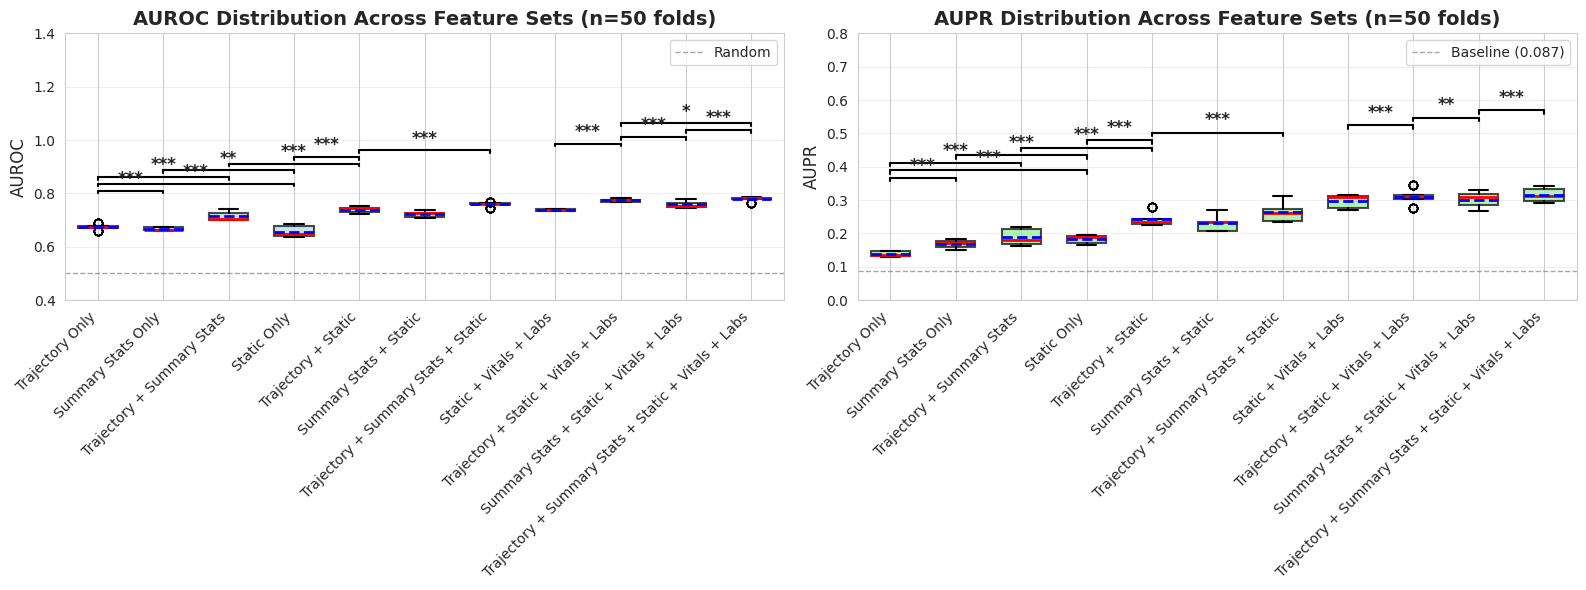


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Summary Stats Only                        0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           -0.0085        +0.0294
Trajectory Only vs Static Only                               0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           -0.0172        +0.0437
Trajectory Only vs Trajectory + Summary Stats                0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.0406        +0.0495
Summary Stats Only vs Static Only                            0.0015       **    0.0000       ***  
  Effect size (Δ):                                           -0.0087        +0.0143
Trajectory + Summary Stats

In [41]:
# Boxplot visualization with statistical significance testing (using shared utilities)
# Define pairwise comparisons
pairs_to_compare = [
    (0, 1),  # Trajectory Only vs Summary Stats Only
    (0, 3),  # Trajectory Only vs Static Only
    (0, 2),  # Trajectory Only vs Trajectory + Summary Stats
    (1, 3),  # Summary Stats Only vs Static Only
    (2, 4),  # Trajectory + Summary Stats vs Trajectory + Static
    (3, 4),  # Static Only vs Trajectory + Static
    (4, 6),  # Trajectory + Static vs Trajectory + Summary Stats + Static
    (7, 8),  # Static + Vitals + Labs vs Trajectory + Static + Vitals + Labs
    (8, 9),  # Trajectory + Static + Vitals + Labs vs Summary Stats + Static + Vitals + Labs
    (9, 10), # Summary Stats + Static + Vitals + Labs vs Trajectory + Summary Stats + Static + Vitals + Labs
    (8, 10)  # Trajectory + Static + Vitals + Labs vs Trajectory + Summary Stats + Static + Vitals + Labs

]

feature_names = list(comparison_results.keys())
n_folds_total = len(comparison_results[feature_names[0]]['roc_auc'])

# Use shared utility function for boxplots with significance testing
fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_weaning_success',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total,
    roc_ylim=(0.4, 1.4),
    ap_ylim=(0.0, 0.8)
)
plt.savefig('../../results/mimic/ventilator/model_comparison_boxplots_significance.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_boxplots_significance.png")
plt.show()

# Print detailed statistical comparisons using shared utility
print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)


✓ Saved: model_comparison_curves.png


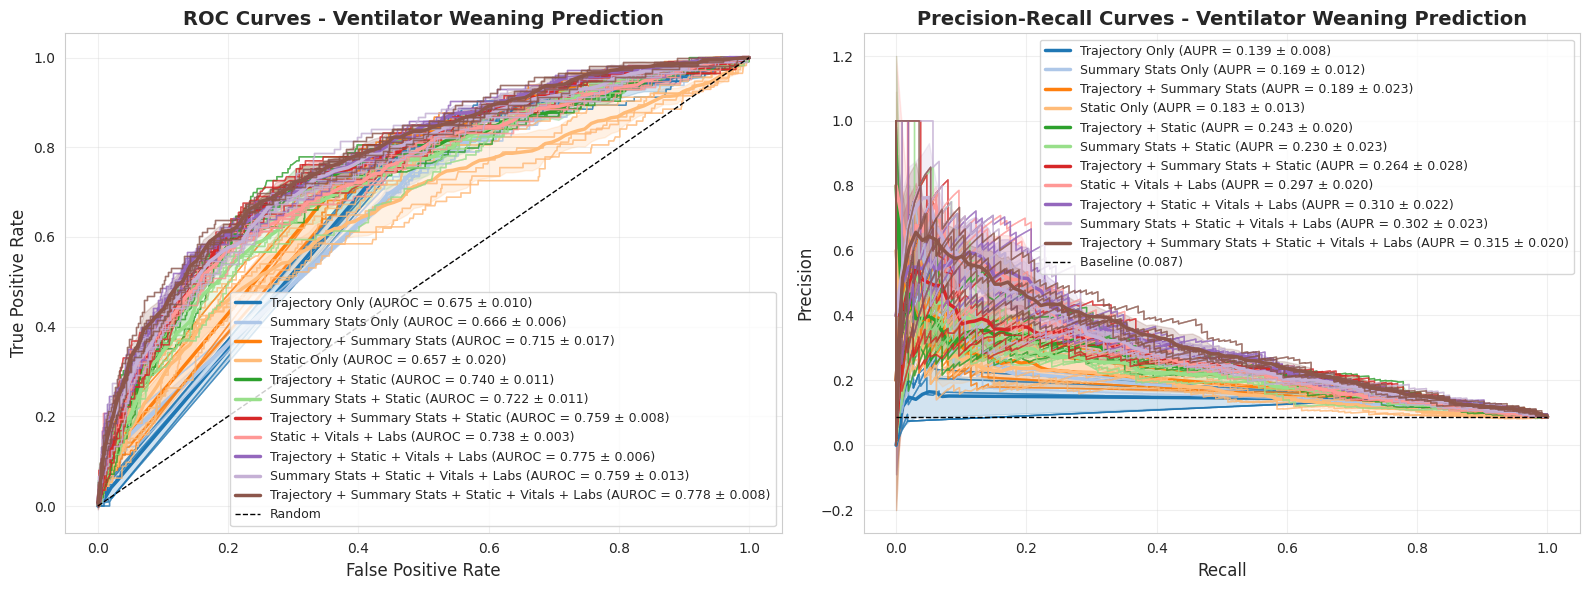

In [42]:
# ROC & PR Curves - Using shared utility function
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=outcome_df,
    target_col='target_weaning_success',
    color_scheme='tab20'
)

# Update titles for ventilator context
ax1.set_title('ROC Curves - Ventilator Weaning Prediction', fontsize=14, fontweight='bold')
ax2.set_title('Precision-Recall Curves - Ventilator Weaning Prediction', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../../results/mimic/ventilator/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: model_comparison_curves.png")
plt.show()

In [36]:
print("\n✓ Ventilator weaning analysis complete!")
print(f"\n  Clinical Impact:")
print(f"    - Predicts successful weaning 48h in advance")
print(f"    - P/F ratio trajectory patterns identify readiness")
print(f"    - Reduces reintubation risk and ventilator-associated complications")


✓ Ventilator weaning analysis complete!

  Clinical Impact:
    - Predicts successful weaning 48h in advance
    - P/F ratio trajectory patterns identify readiness
    - Reduces reintubation risk and ventilator-associated complications
